# Experiment Design

## Objective

The primary objective of this project is to model and analyse **LendingClub credit grade (A–G)** as the main target variable.  
The task is treated as a **multiclass classification problem**, where grade represents the platform’s internal credit risk segmentation.

---

## Target Definition

- **Primary Target:** `grade` (A–G only)
- Encoded as ordinal classes (A=0, …, G=6)
- No sub-grade modelling in this phase
- Probability of Default (PD) is treated as a **secondary validation outcome**, not the modelling target

---

## Data Restriction

To avoid incomplete loan performance and label leakage:

- Only loans issued **before December 2016** are included
- This ensures sufficient performance history

### Time-Based Split (Out-of-Time Validation)

- **Training set:** 2007–2014
- **Test set:** 2015–2016

This split mimics real-world deployment and tests model stability across time.

---

## Evaluation Metrics

All models will be evaluated using:

- **Macro F1 Score (Primary Metric)**  
  Treats all grades equally and prevents dominance by majority classes.

- **Balanced Accuracy**  
  Measures average recall across all grades.

- **Top-2 Accuracy**  
  Measures whether the true grade is within the model’s top two predicted classes.  
  This is particularly relevant for ordinal risk segmentation problems where adjacent-grade confusion is acceptable.

---

## Feature Experiments

Two modelling configurations will be tested:

### 1. Clean Model (No `int_rate`)
- Excludes `int_rate`
- Evaluates whether borrower fundamentals alone explain grade assignment

### 2. Policy-Augmented Model (With `int_rate`)
- Includes `int_rate`
- Demonstrates the structural linkage between pricing and grade
- Used to assess circularity and policy-driven effects

---

## Model Strategy

- Baseline: Multinomial Logistic Regression
- Complex models: Tree-based ensemble methods
- Class imbalance handled using weight balancing
- Hyperparameter tuning applied to best-performing model
- SHAP used for explainability

---

This experimental framework ensures methodological rigor, prevents temporal leakage, and enables robust comparison between borrower-driven and policy-influenced grade modelling.

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight


from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score
)

sns.set_context("notebook")
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42

# Primary target
TARGET_GRADE_COL = "grade"
# Secondary (validation-only) outcome
PD_COL = "PD_24m"  

# Date column for time-based split
DATE_COL = "issue_d"
YEAR_COL = "issue_year"

grade_order = ["A","B","C","D","E","F","G"]
grade_to_int = {g:i for i,g in enumerate(grade_order)}
int_to_grade = {v:k for k,v in grade_to_int.items()}

In [3]:
data = pd.read_csv("accepted_2007_to_2018Q4.csv", nrows = 250000, low_memory=False)

data.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print(data.shape)
data.columns.tolist()

(250000, 151)


['id',
 'member_id',
 'loan_amnt',
 'funded_amnt',
 'funded_amnt_inv',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_title',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'issue_d',
 'loan_status',
 'pymnt_plan',
 'url',
 'desc',
 'purpose',
 'title',
 'zip_code',
 'addr_state',
 'dti',
 'delinq_2yrs',
 'earliest_cr_line',
 'fico_range_low',
 'fico_range_high',
 'inq_last_6mths',
 'mths_since_last_delinq',
 'mths_since_last_record',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'initial_list_status',
 'out_prncp',
 'out_prncp_inv',
 'total_pymnt',
 'total_pymnt_inv',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_d',
 'last_pymnt_amnt',
 'next_pymnt_d',
 'last_credit_pull_d',
 'last_fico_range_high',
 'last_fico_range_low',
 'collections_12_mths_ex_med',
 'mths_since_last_major_derog',
 'policy_code',
 'application_type',
 'annual_inc_joint',
 '

In [5]:
cols_to_use = [
    'id',                     
    'loan_amnt',
    'term',
    'int_rate',
    'installment',
    'grade',
    'sub_grade',
    'emp_length',
    'home_ownership',
    'annual_inc',
    'verification_status',
    'issue_d',
    'loan_status',
    'purpose',
    'addr_state',
    'dti',
    'delinq_2yrs',
    'fico_range_low',
    'fico_range_high',
    'inq_last_6mths',
    'open_acc',
    'pub_rec',
    'revol_bal',
    'revol_util',
    'total_acc',
    'application_type'
]

df_model = pd.read_csv( "accepted_2007_to_2018Q4.csv", usecols=cols_to_use, low_memory=False)

print("df_model shape:", df_model.shape)
df_model.head(3)

df_model shape: (2260701, 26)


,id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,...,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,application_type
0,68407277,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,...,0.0,675.0,679.0,1.0,7.0,0.0,2765.0,29.7,13.0,Individual
1,68355089,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,...,1.0,715.0,719.0,4.0,22.0,0.0,21470.0,19.2,38.0,Individual
2,68341763,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,...,0.0,695.0,699.0,0.0,6.0,0.0,7869.0,56.2,18.0,Joint App


,count
float64,14
object,12


,missing_%
emp_length,6.50
revol_util,0.08
dti,0.08
inq_last_6mths,0.00
total_acc,0.00
pub_rec,0.00
open_acc,0.00
delinq_2yrs,0.00
annual_inc,0.00
purpose,0.00


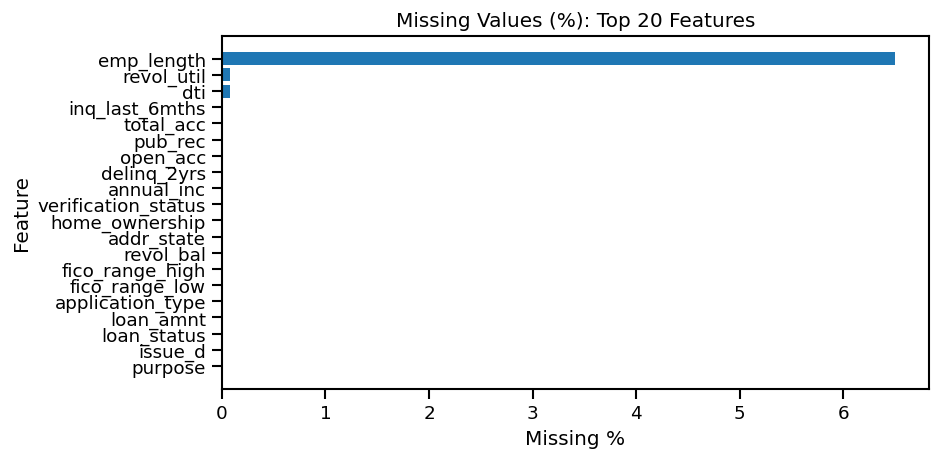

In [6]:
dtype_summary = df_model.dtypes.value_counts().to_frame("count")
dtype_summary.index = dtype_summary.index.astype(str)
display(dtype_summary)

missing_pct = (df_model.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.head(20).to_frame("missing_%").round(2))

plt.figure(figsize=(8,4))
missing_top = missing_pct.head(20).sort_values()
plt.barh(missing_top.index, missing_top.values)
plt.title("Missing Values (%): Top 20 Features")
plt.xlabel("Missing %")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [7]:
before = len(df_model)
df_model = df_model.drop_duplicates(subset=["id"]).copy()
print(f"Dropped {before - len(df_model)} duplicate ids")

def pct_to_float(s):
    return pd.to_numeric(
        s.astype(str).str.replace("%", "", regex=False).str.strip(),
        errors="coerce"
    )

for col in ["int_rate", "revol_util"]:
    if col in df_model.columns:
        df_model[col] = pct_to_float(df_model[col])

numeric_cols_to_force = [
    "loan_amnt","installment","annual_inc","dti","delinq_2yrs",
    "fico_range_low","fico_range_high","inq_last_6mths","open_acc",
    "pub_rec","revol_bal","total_acc"
]
for col in numeric_cols_to_force:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

df_model = df_model.replace([np.inf, -np.inf], np.nan)

checks = {}
if "annual_inc" in df_model.columns:
    checks["annual_inc_negative"] = int((df_model["annual_inc"] < 0).sum())
if "loan_amnt" in df_model.columns:
    checks["loan_amnt_negative"] = int((df_model["loan_amnt"] < 0).sum())
print("Validity check counts:", checks)

cat_cols = ["home_ownership","verification_status","purpose","addr_state","application_type","emp_length"]
for col in cat_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype(str).str.strip().replace({"nan": np.nan, "None": np.nan})

Dropped 0 duplicate ids
Validity check counts: {'annual_inc_negative': 0, 'loan_amnt_negative': 0}


In [8]:
print(df_model['issue_d'].head())

0    Dec-2015
1    Dec-2015
2    Dec-2015
3    Dec-2015
4    Dec-2015
Name: issue_d, dtype: object


In [9]:
df_model[DATE_COL] = pd.to_datetime(df_model[DATE_COL], format='%b-%Y', errors='coerce')
df_model["issue_year"] = df_model[DATE_COL].dt.year

print("issue_year min/max:", df_model["issue_year"].min(), df_model["issue_year"].max())
print("Rows with missing issue_year:", df_model["issue_year"].isna().sum())

issue_year min/max: 2007.0 2018.0
Rows with missing issue_year: 33


,count,percent
grade,,
A,433027,19.15
B,663557,29.35
C,650053,28.75
D,324424,14.35
E,135639,6.00
F,41800,1.85
G,12168,0.54


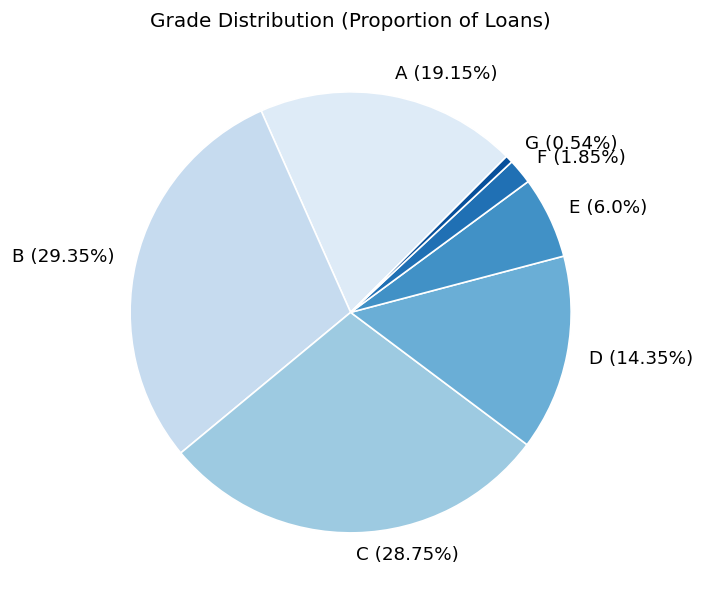

In [10]:
grade_dist = df_model[TARGET_GRADE_COL].value_counts().sort_index()
grade_pct = (grade_dist / len(df_model) * 100).round(2)
display(pd.DataFrame({"count": grade_dist, "percent": grade_pct}))

plt.figure(figsize=(6,6))

plt.pie(
    grade_pct.values,
    labels=[f"{g} ({p}%)" for g, p in zip(grade_pct.index, grade_pct.values)],
    startangle=45,
    colors=sns.color_palette("Blues", len(grade_pct)),
    wedgeprops={"edgecolor": "white"}
)

plt.title("Grade Distribution (Proportion of Loans)")
plt.tight_layout()
plt.show()

,issue_year,loan_count
0,2007.0,603
1,2008.0,2393
2,2009.0,5281
3,2010.0,12537
4,2011.0,21721
5,2012.0,53367
6,2013.0,134814
7,2014.0,235629
8,2015.0,421095
9,2016.0,434407


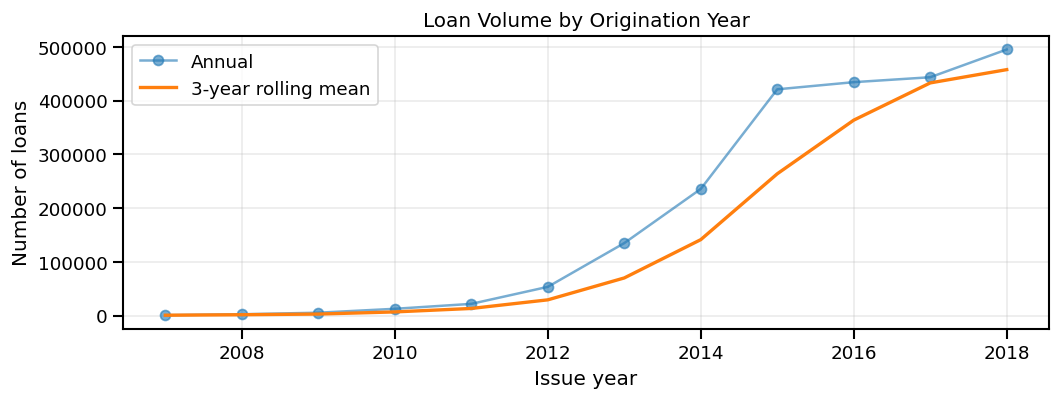

In [11]:
vol = df_model.groupby("issue_year").size().reset_index(name="loan_count").sort_values("issue_year")
display(vol.tail(15))

vol["rolling_3yr"] = vol["loan_count"].rolling(3, min_periods=1).mean()

plt.figure(figsize=(9,3.5))
plt.plot(vol["issue_year"], vol["loan_count"], marker="o", alpha=0.6, label="Annual")
plt.plot(vol["issue_year"], vol["rolling_3yr"], linewidth=2, label="3-year rolling mean")
plt.title("Loan Volume by Origination Year")
plt.xlabel("Issue year")
plt.ylabel("Number of loans")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1200x480 with 0 Axes>

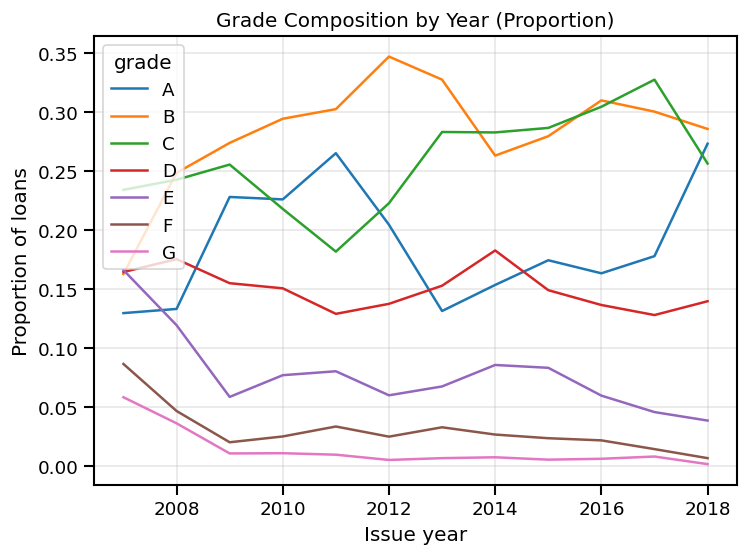

In [12]:
grade_year = (
    df_model.groupby([YEAR_COL, TARGET_GRADE_COL]).size()
    .reset_index(name="n")
)
total_year = df_model.groupby(YEAR_COL).size().rename("total").reset_index()
grade_year = grade_year.merge(total_year, on=YEAR_COL, how="left")
grade_year["pct"] = grade_year["n"] / grade_year["total"]

pivot = grade_year.pivot(index=YEAR_COL, columns=TARGET_GRADE_COL, values="pct").fillna(0)
pivot = pivot.reindex(columns=grade_order)

plt.figure(figsize=(10,4))
pivot.plot(kind="line")
plt.title("Grade Composition by Year (Proportion)")
plt.xlabel("Issue year")
plt.ylabel("Proportion of loans")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
df_model["fico_avg"] = (df_model["fico_range_low"] + df_model["fico_range_high"]) / 2

df_model = df_model.drop(columns=['fico_range_low', 'fico_range_high'])

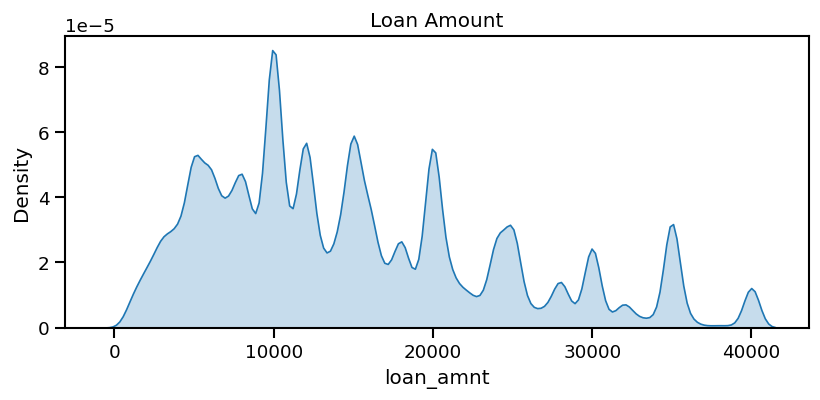

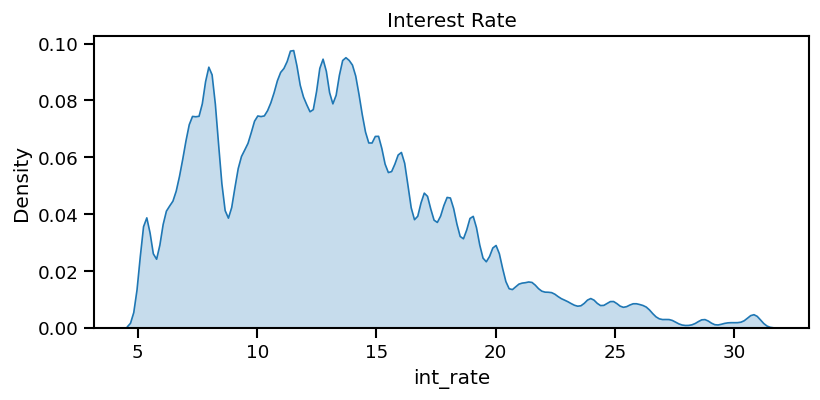

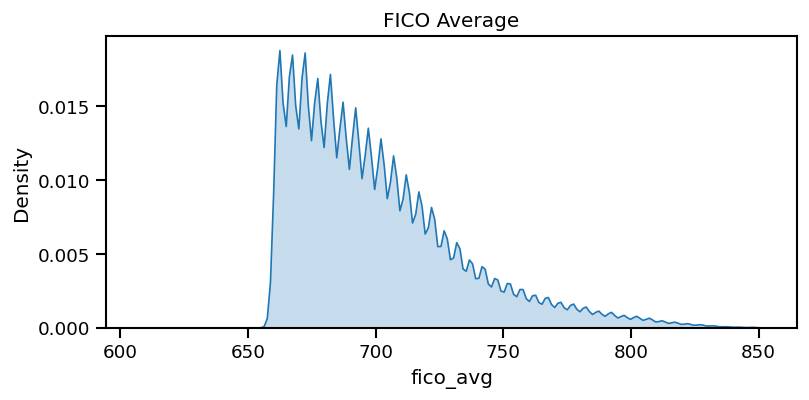

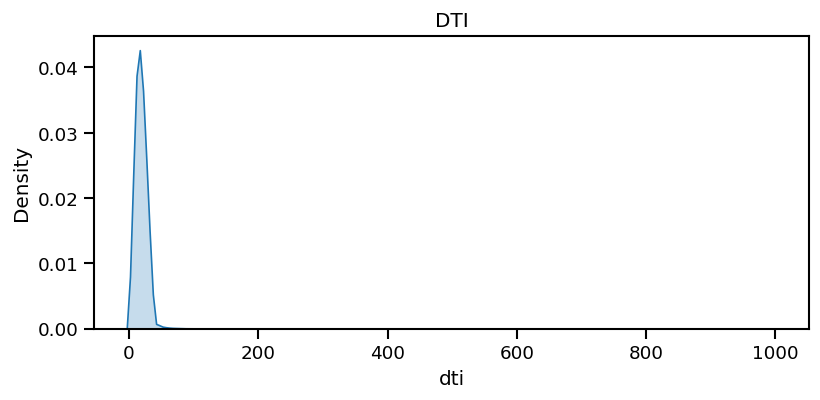

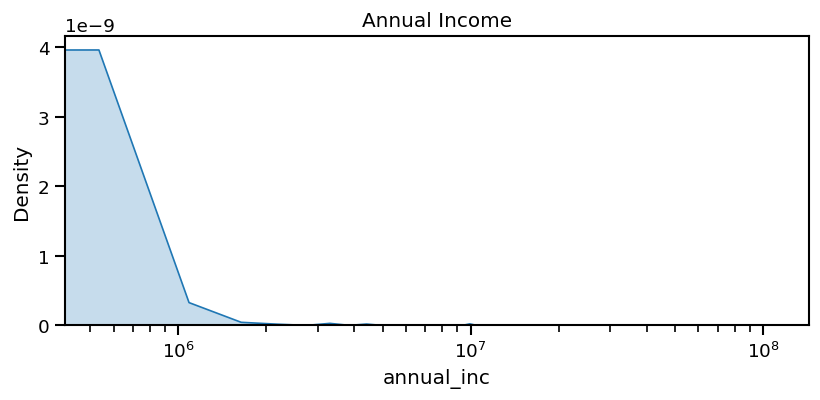

In [14]:
def kde_plot(col, title, log_x=False):
    s = df_model[col].dropna()
    plt.figure(figsize=(7,3.5))
    sns.kdeplot(s, fill=True)
    if log_x:
        plt.xscale("log")
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()

kde_plot("loan_amnt", "Loan Amount")
kde_plot("int_rate", "Interest Rate")
kde_plot("fico_avg", "FICO Average")
kde_plot("dti", "DTI")
kde_plot("annual_inc", "Annual Income", log_x=True)

,count
term,
36 months,1609754
60 months,650914


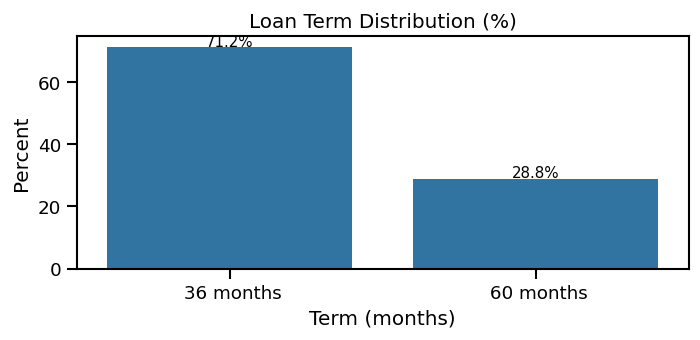

In [15]:
term_counts = df_model["term"].value_counts().sort_index()
display(term_counts.to_frame("count"))

term_pct = (term_counts / term_counts.sum() * 100).round(1)

plt.figure(figsize=(6,3))
ax = sns.barplot(x=term_counts.index.astype(str), y=term_pct.values)
plt.title("Loan Term Distribution (%)")
plt.xlabel("Term (months)")
plt.ylabel("Percent")
for i, v in enumerate(term_pct.values):
    ax.text(i, v + 0.5, f"{v}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

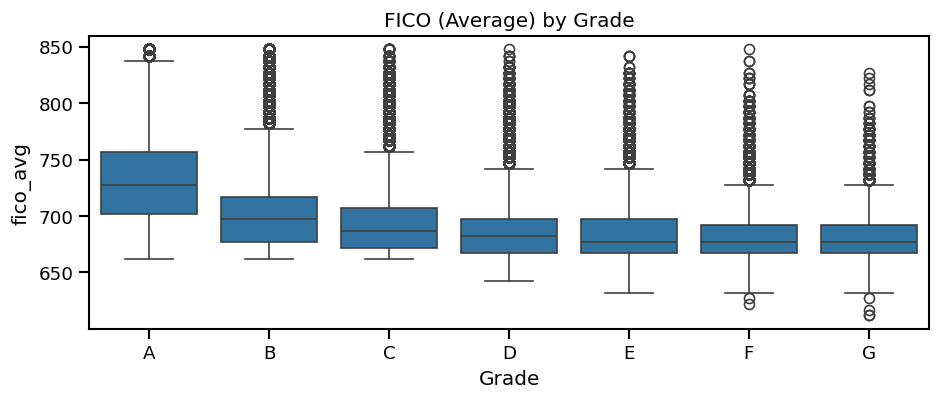

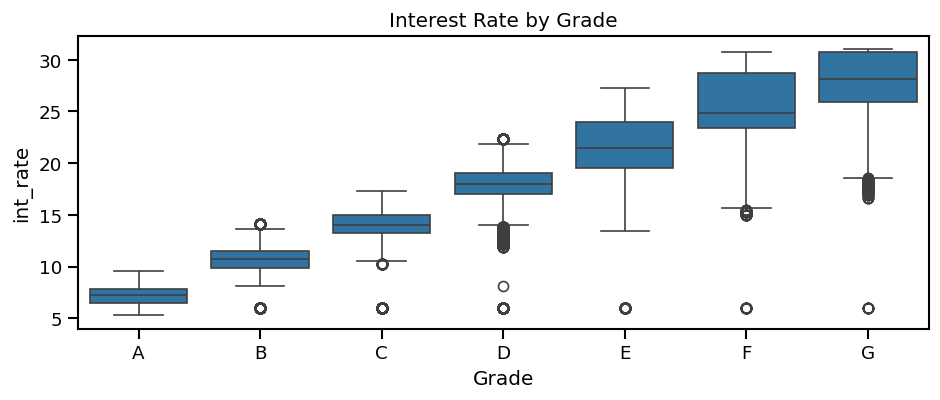

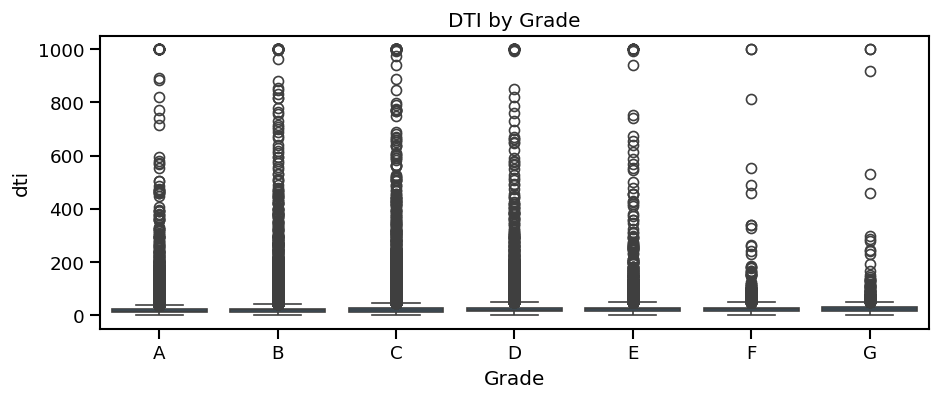

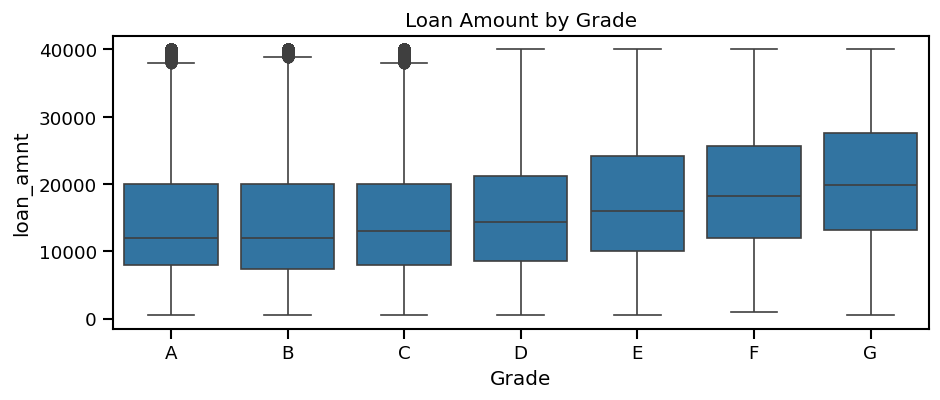

In [16]:
def box_by_grade(col, title):
    plt.figure(figsize=(8,3.5))
    sns.boxplot(data=df_model, x=TARGET_GRADE_COL, y=col, order=grade_order)
    plt.title(title)
    plt.xlabel("Grade")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

box_by_grade("fico_avg", "FICO (Average) by Grade")
box_by_grade("int_rate", "Interest Rate by Grade")
box_by_grade("dti", "DTI by Grade")
box_by_grade("loan_amnt", "Loan Amount by Grade")

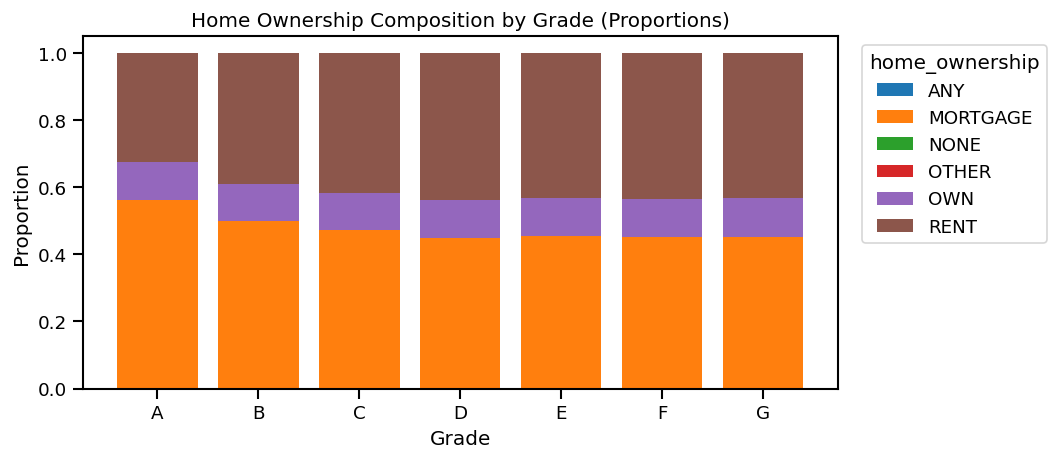

In [17]:
tmp = (
    df_model.groupby([TARGET_GRADE_COL, "home_ownership"]).size()
    .reset_index(name="n")
)
totals = tmp.groupby(TARGET_GRADE_COL)["n"].transform("sum")
tmp["pct"] = tmp["n"] / totals

# Pivot for stacked bars
piv = tmp.pivot(index=TARGET_GRADE_COL, columns="home_ownership", values="pct").fillna(0)
piv = piv.reindex(index=grade_order)

plt.figure(figsize=(9,4))
bottom = np.zeros(len(piv))
for col in piv.columns:
    plt.bar(piv.index, piv[col].values, bottom=bottom, label=str(col))
    bottom += piv[col].values

plt.title("Home Ownership Composition by Grade (Proportions)")
plt.xlabel("Grade")
plt.ylabel("Proportion")
plt.legend(title="home_ownership", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [18]:
df_model["term"] = df_model["term"].astype(str).str.extract(r"(\d+)").astype(float)

df_model["emp_length_num"] = (
    df_model["emp_length"].astype(str)
    .str.replace(r"\+ years", "", regex=True)
    .str.replace(r" years", "", regex=True)
    .str.replace(r" year", "", regex=True)
    .str.replace(r"< 1", "0", regex=True)
    .replace("n/a", np.nan)
)
df_model["emp_length_num"] = pd.to_numeric(df_model["emp_length_num"], errors="coerce")

df_model[["term","emp_length","emp_length_num", "fico_avg"]].head(5)

,term,emp_length,emp_length_num,fico_avg
0,36.0,10+ years,10.0,677.0
1,36.0,10+ years,10.0,717.0
2,60.0,10+ years,10.0,697.0
3,60.0,10+ years,10.0,787.0
4,60.0,3 years,3.0,697.0


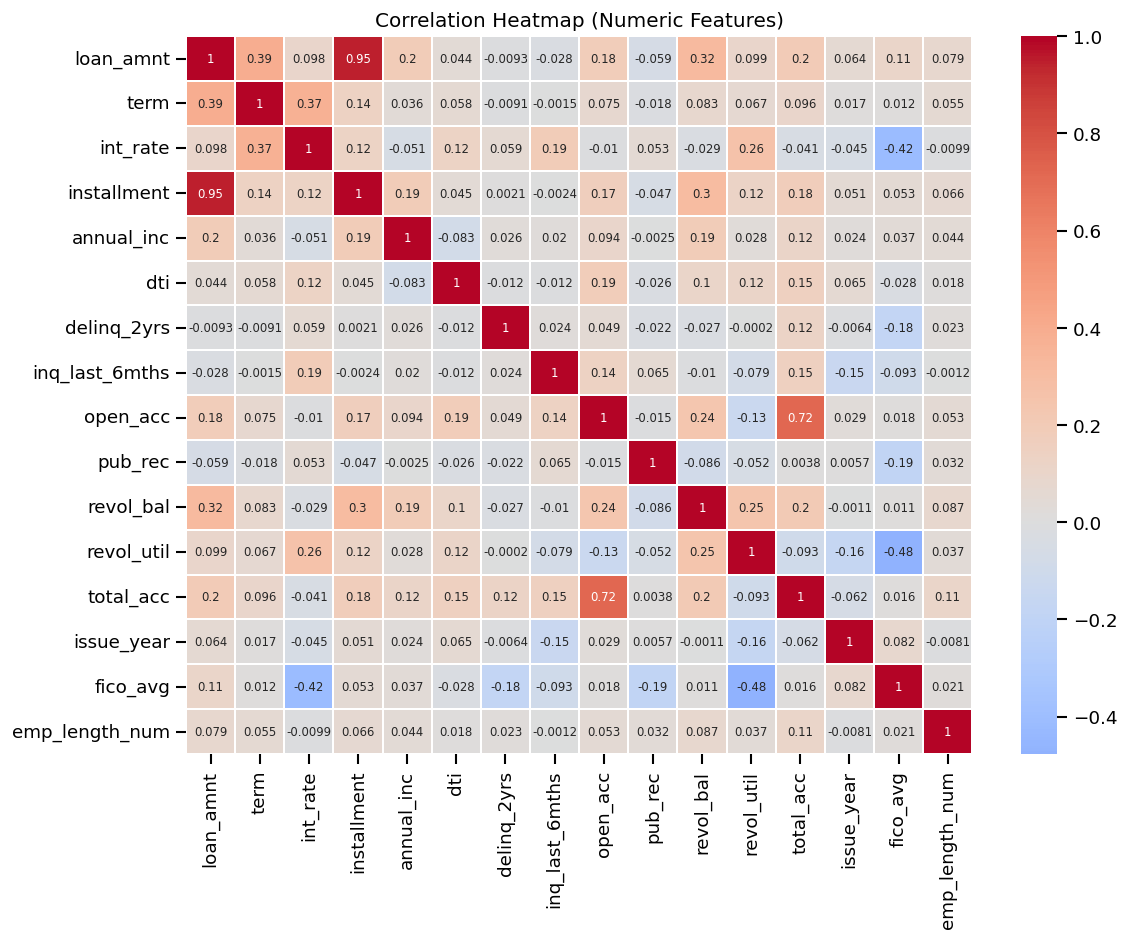

,feature_1,feature_2,corr
0,loan_amnt,installment,0.945625


In [19]:
num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()

corr = df_model[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2, annot = True, annot_kws={"size": 7})
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

threshold = 0.80
pairs = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        v = corr.iloc[i, j]
        if abs(v) >= threshold:
            pairs.append((cols[i], cols[j], v))

high_corr_pairs = pd.DataFrame(pairs, columns=["feature_1","feature_2","corr"]).sort_values("corr", ascending=False)
display(high_corr_pairs.head(25))

In [20]:
print("Before: \n", df_model['loan_status'].value_counts())

df_model = df_model[df_model['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default'])].copy()

print("\nAfter: \n",df_model['loan_status'].value_counts())
df_model.shape

Before: 
 loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

After: 
 loan_status
Fully Paid     1076751
Charged Off     268559
Default             40
Name: count, dtype: int64


(1345350, 27)

In [21]:
df_model['PD_24m'] = df_model['loan_status'].apply(
    lambda x: 1 if x in ['Charged Off', 'Default'] else 0
)

In [22]:
print("PD distribution:")
display(df_model[PD_COL].value_counts(dropna=False).sort_index())
print("Default rate (mean PD):", df_model[PD_COL].mean())

PD distribution:


PD_24m
0    1076751
1     268599
Name: count, dtype: int64

Default rate (mean PD): 0.19964990522912254


,mean,count,mean_pct
grade,,,
A,0.060427,235095,6.042664
B,0.133867,392748,13.386701
C,0.224413,381694,22.441275
D,0.303867,200966,30.386732
E,0.384823,93656,38.482318
F,0.452042,32059,45.204155
G,0.499343,9132,49.934297


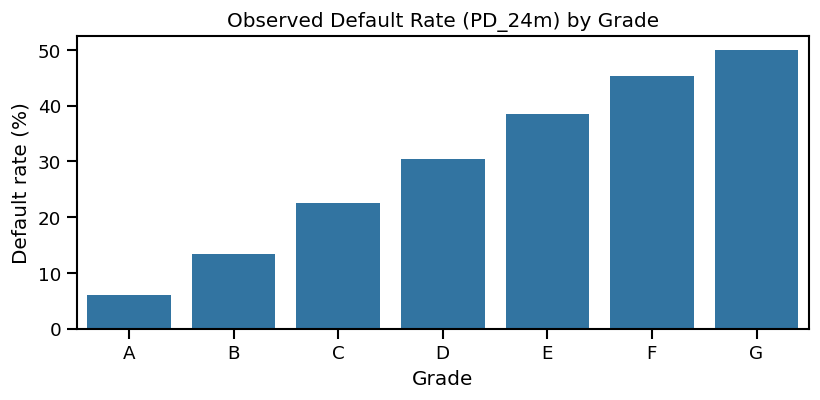

In [23]:
pd_by_grade = df_model.groupby(TARGET_GRADE_COL)[PD_COL].agg(["mean","count"]).reindex(grade_order)
pd_by_grade["mean_pct"] = pd_by_grade["mean"] * 100
display(pd_by_grade)

plt.figure(figsize=(7,3.5))
sns.barplot(x=pd_by_grade.index, y=pd_by_grade["mean_pct"].values)
plt.title(f"Observed Default Rate ({PD_COL}) by Grade")
plt.xlabel("Grade")
plt.ylabel("Default rate (%)")
plt.tight_layout()
plt.show()

,mean,median,count
grade,,,
A,7.113041,7.26,235095
B,10.679136,10.91,392748
C,14.021231,13.99,381694
D,17.721692,17.57,200966
E,21.138302,20.99,93656
F,24.934966,24.24,32059
G,27.725938,27.34,9132


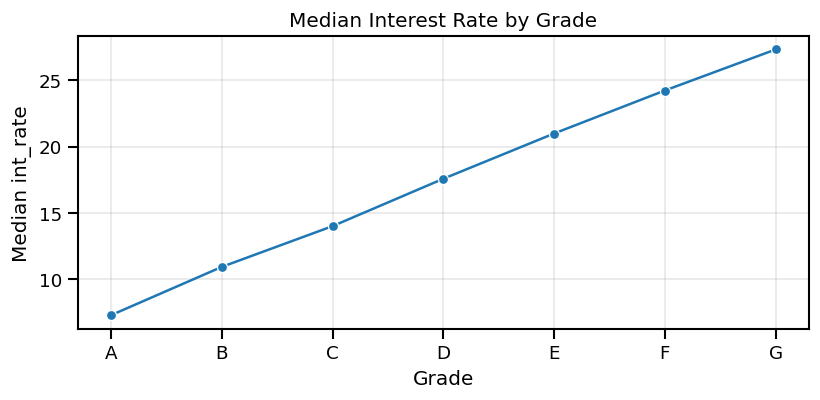

In [24]:
rate_summary = df_model.groupby(TARGET_GRADE_COL)["int_rate"].agg(["mean","median","count"]).reindex(grade_order)
display(rate_summary)

plt.figure(figsize=(7,3.5))
sns.lineplot(x=rate_summary.index, y=rate_summary["median"].values, marker="o")
plt.title("Median Interest Rate by Grade")
plt.xlabel("Grade")
plt.ylabel("Median int_rate")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
eda_summary = {
    "rows": int(df_model.shape[0]),
    "cols": int(df_model.shape[1]),
    "years_min": int(df_model[YEAR_COL].min()) if pd.notna(df_model[YEAR_COL].min()) else None,
    "years_max": int(df_model[YEAR_COL].max()) if pd.notna(df_model[YEAR_COL].max()) else None,
    "grade_counts": df_model[TARGET_GRADE_COL].value_counts().to_dict(),
    "top_missing_cols": missing_pct.head(10).index.tolist()
}

eda_summary["overall_default_rate"] = float(df_model[PD_COL].mean())

eda_summary

{'rows': 1345350,
 'cols': 28,
 'years_min': 2007,
 'years_max': 2018,
 'grade_counts': {'B': 392748,
  'C': 381694,
  'A': 235095,
  'D': 200966,
  'E': 93656,
  'F': 32059,
  'G': 9132},
 'top_missing_cols': ['emp_length',
  'revol_util',
  'dti',
  'inq_last_6mths',
  'total_acc',
  'pub_rec',
  'open_acc',
  'delinq_2yrs',
  'annual_inc',
  'purpose'],
 'overall_default_rate': 0.19964990522912254}

In [26]:
df_model["annual_inc_log"] = np.log1p(df_model["annual_inc"])

In [27]:
df_model = df_model[df_model[TARGET_GRADE_COL].isin(grade_order)].copy()

df_model["grade_encoded"] = df_model[TARGET_GRADE_COL].map(grade_to_int).astype(int)

print(df_model[TARGET_GRADE_COL].value_counts().sort_index())

grade
A    235095
B    392748
C    381694
D    200966
E     93656
F     32059
G      9132
Name: count, dtype: int64


In [28]:
cutoff_date = pd.Timestamp("2016-12-01")
df_model = df_model[df_model["issue_d"] <= cutoff_date].copy()

train_df = df_model[df_model["issue_year"].between(2007, 2014, inclusive="both")].copy()
test_df  = df_model[df_model["issue_year"].between(2015, 2016, inclusive="both")].copy()

print("Train size:", train_df.shape, "| years:", train_df["issue_year"].min(), "-", train_df["issue_year"].max())
print("Test size :", test_df.shape,  "| years:", test_df["issue_year"].min(),  "-", test_df["issue_year"].max())

print("Train grade counts:\n", train_df["grade"].value_counts().reindex(grade_order))
print("Test grade counts:\n", test_df["grade"].value_counts().reindex(grade_order))

Train size: (451060, 30) | years: 2007.0 - 2014.0
Test size : (668651, 30) | years: 2015.0 - 2016.0
Train grade counts:
 grade
A     74540
B    134595
C    120618
D     72522
E     33335
F     12481
G      2969
Name: count, dtype: int64
Test grade counts:
 grade
A    120845
B    195919
C    191402
D     94248
E     47075
F     15269
G      3893
Name: count, dtype: int64


In [29]:
numeric_features_base = [
    "loan_amnt",
    "term",
    "installment",
    "emp_length_num",
    "annual_inc_log",
    "dti",
    "delinq_2yrs",
    "fico_avg",
    "inq_last_6mths",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc"
]

categorical_features = [
    "home_ownership",
    "verification_status",
    "purpose",
    "addr_state",
    "application_type"
]

# Model 1: exclude interest rate 
features_no_rate_num = numeric_features_base
features_no_rate_cat = categorical_features

# Model 2: include interest rate 
features_with_rate_num = numeric_features_base + ["int_rate"]
features_with_rate_cat = categorical_features

def check_features(df_, nums, cats):
    missing = [c for c in (nums + cats) if c not in df_.columns]
    if missing:
        print("Missing feature columns:", missing)
    else:
        print("All features present.")

check_features(train_df, features_no_rate_num, features_no_rate_cat)
check_features(train_df, features_with_rate_num, features_with_rate_cat)

All features present.
All features present.


In [30]:
before = len(train_df)
train_df = train_df.dropna(subset=[TARGET_GRADE_COL]).copy()
print(f"Dropped {before - len(train_df)} train rows with missing grade")

before = len(test_df)
test_df = test_df.dropna(subset=[TARGET_GRADE_COL]).copy()
print(f"Dropped {before - len(test_df)} test rows with missing grade")

num_check = [c for c in numeric_features_base + ["int_rate"] if c in df_model.columns]
bad = [c for c in num_check if df_model[c].dtype == "object"]
print("Numeric cols still object dtype:", bad)

Dropped 0 train rows with missing grade
Dropped 0 test rows with missing grade
Numeric cols still object dtype: []


In [31]:
def make_preprocessor(numeric_cols, categorical_cols, scale_numeric=True):

    num_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))

    numeric_transformer = Pipeline(steps=num_steps)

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols),
        ],
        remainder="drop"
    )

    return preprocessor

In [32]:
y_train = train_df["grade_encoded"]
y_test = test_df["grade_encoded"]

X_train_no_rate = train_df[features_no_rate_num + features_no_rate_cat]
X_test_no_rate  = test_df[features_no_rate_num + features_no_rate_cat]

X_train_with_rate = train_df[features_with_rate_num + features_with_rate_cat]
X_test_with_rate  = test_df[features_with_rate_num + features_with_rate_cat]

print(X_train_no_rate.shape, X_test_no_rate.shape)
print(X_train_with_rate.shape, X_test_with_rate.shape)

(451060, 19) (668651, 19)
(451060, 20) (668651, 20)


In [33]:
def top_k_accuracy(y_true, proba, k=2):
    topk = np.argsort(proba, axis=1)[:, -k:]
    y_true = np.array(y_true)
    return np.mean([y_true[i] in topk[i] for i in range(len(y_true))])

def evaluate_model(pipe, X_train, y_train, X_test, y_test, label, feature_set_name, sample_weight=None):

    if sample_weight is not None:
        pipe.fit(X_train, y_train, clf__sample_weight=sample_weight)
    else:
        pipe.fit(X_train, y_train)

    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)

    bal_acc = balanced_accuracy_score(y_test, pred)
    macro_f1 = f1_score(y_test, pred, average="macro")
    top2 = top_k_accuracy(y_test, proba, k=2)

    print(f"\n----- {label} -----")
    print("Balanced Accuracy:", round(bal_acc,4))
    print("Macro F1:", round(macro_f1,4))
    print("Top-2 Accuracy:", round(top2,4))

    return {
        "model": label,
        "experiment": feature_set_name,
        "balanced_accuracy": bal_acc,
        "macro_f1": macro_f1,
        "top2_accuracy": top2
    }

In [34]:
pre_no_rate = make_preprocessor(features_no_rate_num, features_no_rate_cat, scale_numeric=True)
pre_with_rate = make_preprocessor(features_with_rate_num, features_with_rate_cat, scale_numeric=True)


logreg_no = Pipeline([
    ("prep", make_preprocessor(features_no_rate_num, features_no_rate_cat, scale_numeric=True)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

rf_no = Pipeline([
    ("prep", make_preprocessor(features_no_rate_num, features_no_rate_cat, scale_numeric=False)),
    ("clf", RandomForestClassifier(
        n_estimators=300, min_samples_leaf=10,
        class_weight="balanced", random_state=42, n_jobs=-1
    ))
])

et_no = Pipeline([
    ("prep", make_preprocessor(features_no_rate_num, features_no_rate_cat, scale_numeric=False)),
    ("clf", ExtraTreesClassifier(
        n_estimators=300, min_samples_leaf=5,
        class_weight="balanced", random_state=42, n_jobs=-1
    ))
])

hgb_no = Pipeline([
    ("prep", make_preprocessor(features_no_rate_num, features_no_rate_cat, scale_numeric=False)),
    ("clf", HistGradientBoostingClassifier(
        max_depth=6, learning_rate=0.1, random_state=42
    ))
])

model_pipelines_no_rate = {
    "LogReg (Balanced) [NO_RATE]": logreg_no,
    "RandomForest (Balanced) [NO_RATE]": rf_no,
    "ExtraTrees (Balanced) [NO_RATE]": et_no,
    "HistGB (Balanced) [NO_RATE]": hgb_no
}

sw_no = compute_sample_weight(class_weight="balanced", y=y_train)

In [35]:
logreg_wr = Pipeline([
    ("prep", make_preprocessor(features_with_rate_num, features_with_rate_cat, scale_numeric=True)),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

rf_wr = Pipeline([
    ("prep", make_preprocessor(features_with_rate_num, features_with_rate_cat, scale_numeric=False)),
    ("clf", RandomForestClassifier(
        n_estimators=300, min_samples_leaf=10,
        class_weight="balanced", random_state=42, n_jobs=-1
    ))
])

et_wr = Pipeline([
    ("prep", make_preprocessor(features_with_rate_num, features_with_rate_cat, scale_numeric=False)),
    ("clf", ExtraTreesClassifier(
        n_estimators=300, min_samples_leaf=5,
        class_weight="balanced", random_state=42, n_jobs=-1
    ))
])

hgb_wr = Pipeline([
    ("prep", make_preprocessor(features_with_rate_num, features_with_rate_cat, scale_numeric=False)),
    ("clf", HistGradientBoostingClassifier(
        max_depth=6, learning_rate=0.1, random_state=42
    ))
])

model_pipelines_with_rate = {
    "LogReg (Balanced) [WITH_RATE]": logreg_wr,
    "RandomForest (Balanced) [WITH_RATE]": rf_wr,
    "ExtraTrees (Balanced) [WITH_RATE]": et_wr,
    "HistGB (Balanced) [WITH_RATE]": hgb_wr
}

sw_wr = compute_sample_weight(class_weight="balanced", y=y_train)

In [43]:
def run_experiment(model_dict, X_train, X_test, y_train, y_test, feature_set_name, sample_weight_for_hgb=None):
    rows = []
    for name, pipe in model_dict.items():
        if "HistGB" in name:
            rows.append(evaluate_model(pipe, X_train, y_train, X_test, y_test, f"{name}", feature_set_name, sample_weight=sample_weight_for_hgb))
        else:
            rows.append(evaluate_model(pipe, X_train, y_train, X_test, y_test, f"{name}", feature_set_name))
    return pd.DataFrame(rows)

In [44]:
results_no = run_experiment(
    model_pipelines_no_rate,
    X_train_no_rate, X_test_no_rate,
    y_train, y_test,
    feature_set_name="NO_RATE",
    sample_weight_for_hgb=sw_no
)

results_wr = run_experiment(
    model_pipelines_with_rate,
    X_train_with_rate, X_test_with_rate,
    y_train, y_test,
    feature_set_name="WITH_RATE",
    sample_weight_for_hgb=sw_wr
)

results_all = pd.concat([results_no, results_wr], ignore_index=True)
results_all = results_all.sort_values("macro_f1", ascending=False)
display(results_all)


----- LogReg (Balanced) [NO_RATE] -----
Balanced Accuracy: 0.4747
Macro F1: 0.3843
Top-2 Accuracy: 0.768

----- RandomForest (Balanced) [NO_RATE] -----
Balanced Accuracy: 0.4003
Macro F1: 0.3771
Top-2 Accuracy: 0.7327

----- ExtraTrees (Balanced) [NO_RATE] -----
Balanced Accuracy: 0.385
Macro F1: 0.3434
Top-2 Accuracy: 0.6997

----- HistGB (Balanced) [NO_RATE] -----
Balanced Accuracy: 0.6349
Macro F1: 0.575
Top-2 Accuracy: 0.9045

----- LogReg (Balanced) [WITH_RATE] -----
Balanced Accuracy: 0.7265
Macro F1: 0.659
Top-2 Accuracy: 0.9872

----- RandomForest (Balanced) [WITH_RATE] -----
Balanced Accuracy: 0.7413
Macro F1: 0.6952
Top-2 Accuracy: 0.9792

----- ExtraTrees (Balanced) [WITH_RATE] -----
Balanced Accuracy: 0.7276
Macro F1: 0.678
Top-2 Accuracy: 0.9812

----- HistGB (Balanced) [WITH_RATE] -----
Balanced Accuracy: 0.7421
Macro F1: 0.6759
Top-2 Accuracy: 0.9754


,model,experiment,balanced_accuracy,macro_f1,top2_accuracy
5,RandomForest (Balanced) [WITH_RATE],WITH_RATE,0.741350,0.695188,0.979200
6,ExtraTrees (Balanced) [WITH_RATE],WITH_RATE,0.727605,0.678046,0.981222
7,HistGB (Balanced) [WITH_RATE],WITH_RATE,0.742088,0.675927,0.975433
4,LogReg (Balanced) [WITH_RATE],WITH_RATE,0.726528,0.658997,0.987176
3,HistGB (Balanced) [NO_RATE],NO_RATE,0.634864,0.575050,0.904488
0,LogReg (Balanced) [NO_RATE],NO_RATE,0.474692,0.384349,0.768011
1,RandomForest (Balanced) [NO_RATE],NO_RATE,0.400341,0.377142,0.732651
2,ExtraTrees (Balanced) [NO_RATE],NO_RATE,0.385034,0.343408,0.699746


In [60]:
best_no = results_all[results_all["experiment"]=="NO_RATE"].sort_values("macro_f1", ascending=False).iloc[0]
best_wr = results_all[results_all["experiment"]=="WITH_RATE"].sort_values("macro_f1", ascending=False).iloc[0]

print("Best NO_RATE:", best_no["model"], best_no["macro_f1"])
print("Best WITH_RATE:", best_wr["model"], best_wr["macro_f1"])

best_no_model_name = best_no["model"]
best_wr_model_name = best_wr["model"]

best_pipe_no = model_pipelines_no_rate[best_no_model_name]
best_pipe_wr = model_pipelines_with_rate[best_wr_model_name]

best_pipe_no.fit(X_train_no_rate, y_train)
pred_no = best_pipe.predict(X_test_no_rate)

best_pipe_wr.fit(X_train_with_rate, y_train)
pred_wr = best_pipe_wr.predict(X_test_with_rate)

Best NO_RATE: HistGB (Balanced) [NO_RATE] 0.5750496692443823
Best WITH_RATE: RandomForest (Balanced) [WITH_RATE] 0.6951876663318739


ValueError: columns are missing: {'int_rate'}

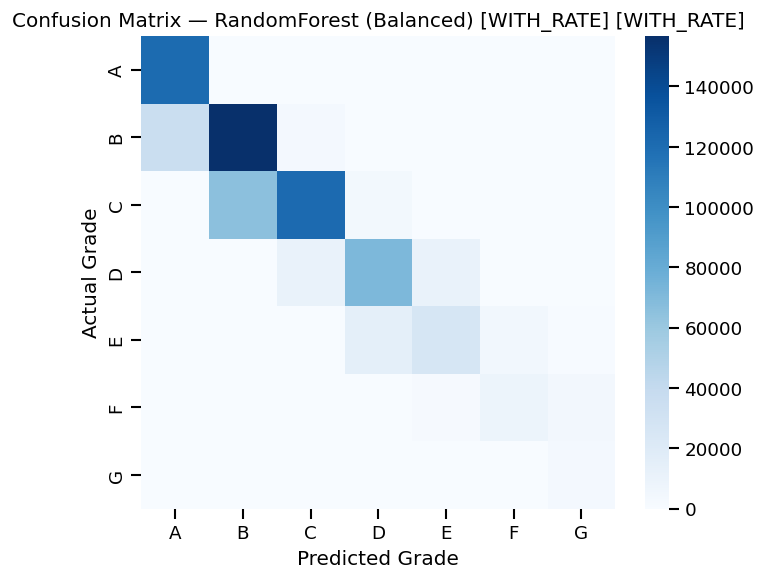

In [46]:
cm = confusion_matrix(y_test, pred, labels=list(range(7)))
cm_df = pd.DataFrame(cm, index=grade_order, columns=grade_order)

plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=False, cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name} [{best_experiment}]")
plt.xlabel("Predicted Grade")
plt.ylabel("Actual Grade")
plt.tight_layout()
plt.show()

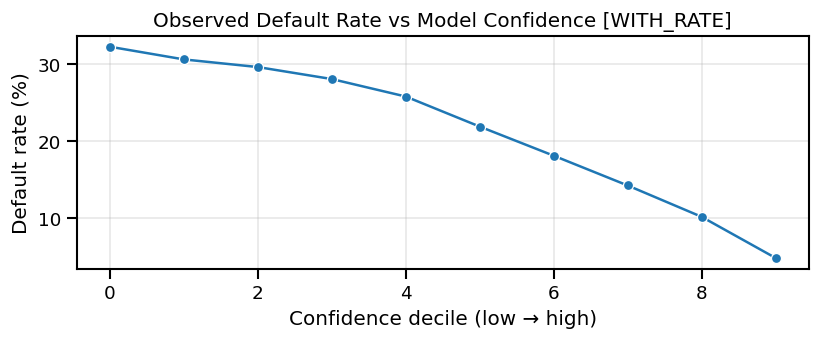

In [47]:
if hasattr(best_pipe, "predict_proba") and PD_COL in test_df.columns:
    proba = best_pipe.predict_proba(X_test_best)
    conf = proba.max(axis=1)

    tmp = test_df.copy()
    tmp["confidence"] = conf
    tmp["pred_grade"] = pred  # already computed on correct X_test

    tmp["conf_decile"] = pd.qcut(tmp["confidence"], 10, labels=False, duplicates="drop")
    conf_pd = tmp.groupby("conf_decile")[PD_COL].agg(["mean","count"]).reset_index()
    conf_pd["mean_pct"] = conf_pd["mean"] * 100

    plt.figure(figsize=(7,3))
    sns.lineplot(data=conf_pd, x="conf_decile", y="mean_pct", marker="o")
    plt.title(f"Observed Default Rate vs Model Confidence [{best_experiment}]")
    plt.xlabel("Confidence decile (low → high)")
    plt.ylabel("Default rate (%)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

,mean,count,mean_pct
grade,,,
A,0.059851,195385,5.985106
B,0.131308,330514,13.130760
C,0.219534,312020,21.953400
D,0.300186,166770,30.018588
E,0.384989,80410,38.498943
F,0.451243,27750,45.124324
G,0.498834,6862,49.883416


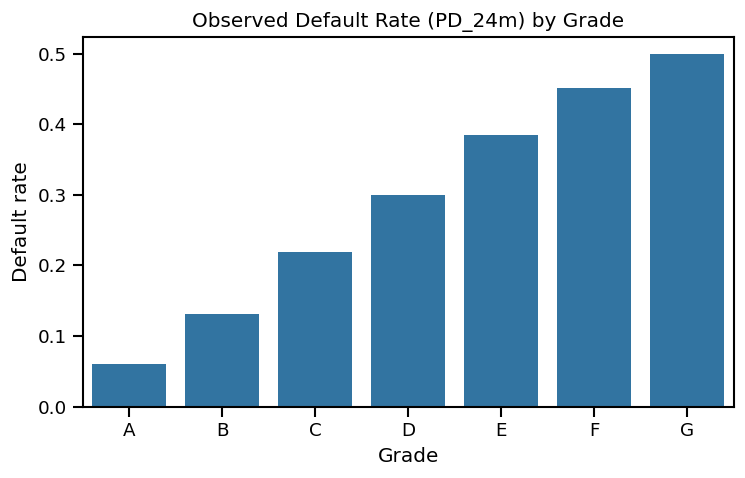

In [48]:
pd_by_grade = df_model.groupby(TARGET_GRADE_COL)[PD_COL].agg(["mean", "count"]).reindex(grade_order)
pd_by_grade["mean_pct"] = pd_by_grade["mean"] * 100
display(pd_by_grade)

plt.figure(figsize=(7,4))
sns.barplot(x=pd_by_grade.index, y=pd_by_grade["mean"])
plt.title(f"Observed Default Rate ({PD_COL}) by Grade")
plt.xlabel("Grade")
plt.ylabel("Default rate")
plt.show()

,median,mean,count
grade,,,
A,7.26,7.137819,195385
B,10.99,10.687139,330514
C,13.98,13.952805,312020
D,17.57,17.468249,166770
E,20.49,20.532283,80410
F,24.08,24.191350,27750
G,25.99,26.683368,6862


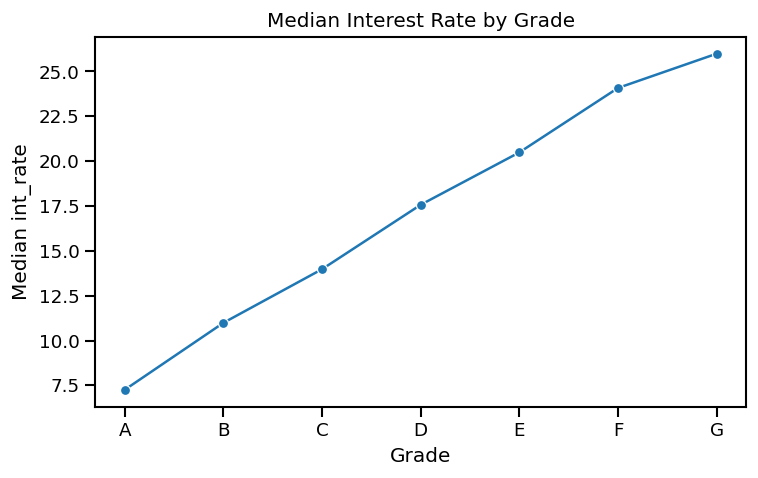

In [49]:
grade_rate = df_model.groupby("grade")["int_rate"].agg(["median","mean","count"]).reindex(grade_order)
display(grade_rate)

plt.figure(figsize=(7,4))
sns.lineplot(x=grade_rate.index, y=grade_rate["median"], marker="o")
plt.title("Median Interest Rate by Grade")
plt.xlabel("Grade")
plt.ylabel("Median int_rate")
plt.show()